# eda


we r goig to do eda on an insurance data


In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('prac.csv')

# eda

In [13]:

df.shape

(1338, 7)

In [14]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [16]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [17]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [18]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
dta=df.columns
dta[0]

'age'

In [20]:
numerical_data=[]

for i in dta:
    if np.dtype(df[i])==int or np.dtype(df[i])==float:
        numerical_data.append(i)

numerical_data

['age', 'bmi', 'children', 'charges']

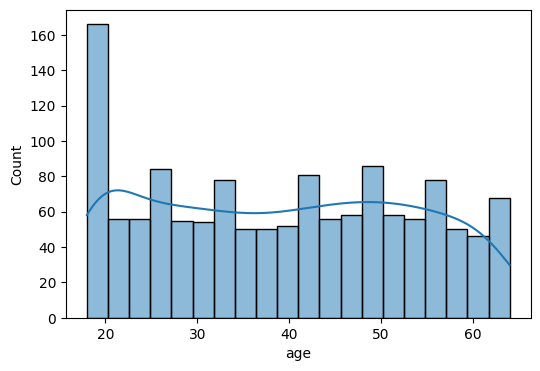

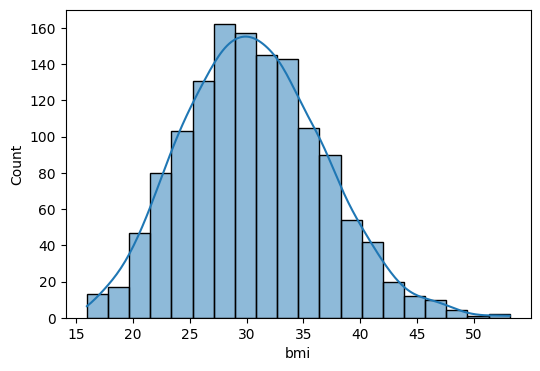

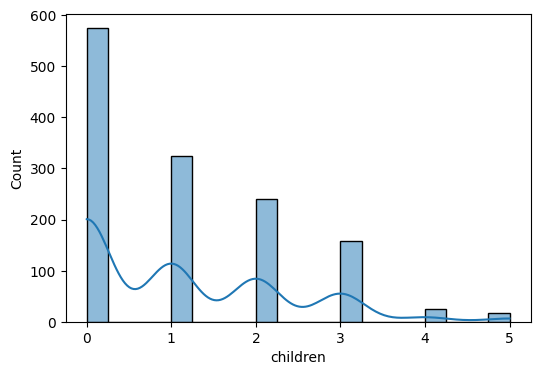

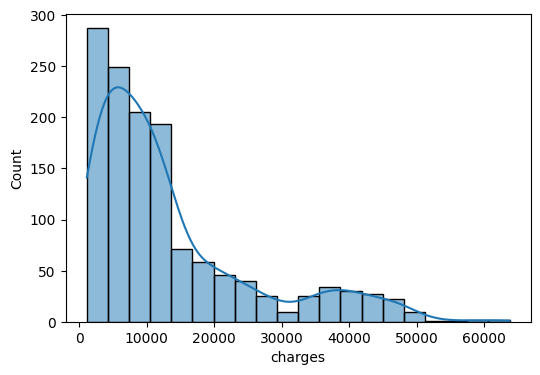

In [21]:
for col in numerical_data:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='age', ylabel='charges'>

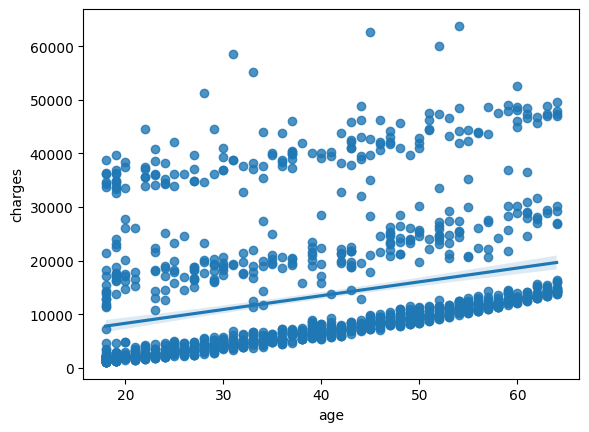

In [24]:
sns.regplot(x=df['age'],y=df['charges'])

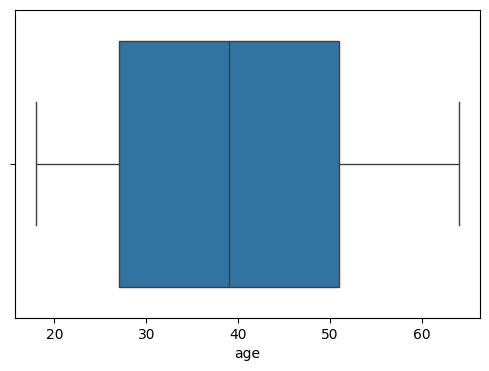

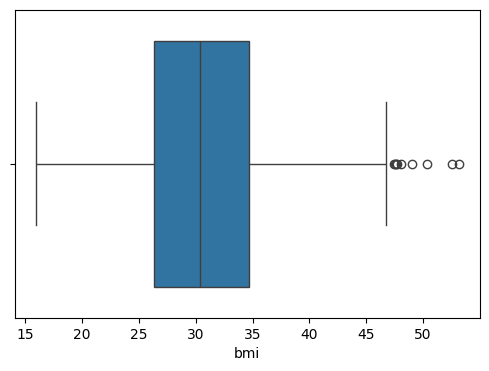

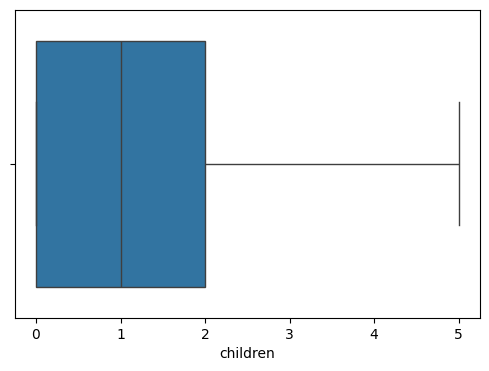

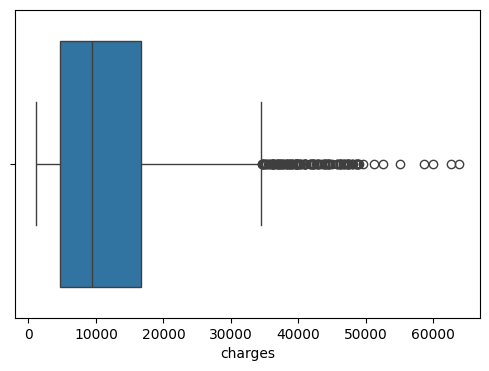

In [26]:
for col in numerical_data:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

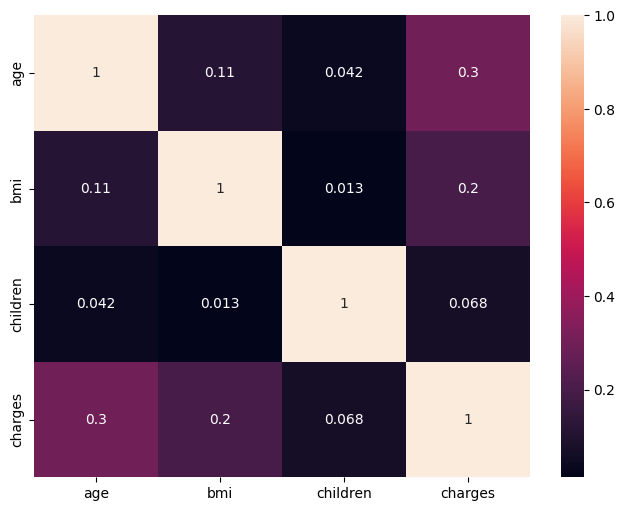

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning


In [32]:
df_cleaned=df.copy()

In [33]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [34]:
df_cleaned.shape

(1338, 7)

In [35]:
df_cleaned.drop_duplicates(inplace=True)

In [36]:
df_cleaned.shape

(1337, 7)

In [37]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [38]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [45]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [40]:
# lets encode sex , smokers and regions

In [49]:
df_cleaned['sex']=df_cleaned['sex'].map({"male":0 , "female":1})

In [50]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [51]:
df_cleaned['smoker']=df_cleaned['smoker'].map({"no":0 , "yes":1})

In [52]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [53]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [54]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [55]:
df_cleaned

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False
1334,18,1,31.920,0,0,2205.98080,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,True


In [56]:
df_cleaned=df_cleaned.astype(int)

In [57]:
df_cleaned

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


# feature engg & extraction

In [58]:
df_cleaned.tail()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1
1337,61,1,29,0,1,29141,1,0,0


bmi category 

1. underweght
2. normal weigth
3. over weight
4. obesity


In [ ]:
df_cleaned['bmi_category']=pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['underweght','normal','overweight','obese']
)

In [61]:
df_cleaned

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,obese
1334,18,1,31,0,0,2205,0,0,0,obese
1335,18,1,36,0,0,1629,0,1,0,obese
1336,21,1,25,0,0,2007,0,0,1,overweight


In [62]:
df_cleaned.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category'],
      dtype='object')

In [65]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']

scaler=StandardScaler()

df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [66]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,overweight
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,obese
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,obese
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,normal
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,overweight


In [78]:
# lets find out correlation between the coulmns vs chaarges 
from scipy.stats import pearsonr

selected_features=['age', 'sex', 'bmi', 'children', 'smoker',
'region_northwest', 'region_southeast', 'region_southwest',
'bmi_category']

In [79]:

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
    if pd.api.types.is_numeric_dtype(df_cleaned[feature])
}
correlation_df=pd.DataFrame(list(correlations.items()),columns=['Feature','Pearson Correlation'])

In [80]:
correlation_df

,Feature,Pearson Correlation
0,age,0.298309
1,sex,-0.058046
2,bmi,0.196236
3,children,0.067390
4,smoker,0.787234
5,region_northwest,-0.038695
6,region_southeast,0.073577
7,region_southwest,-0.043637


In [89]:
correlation_df.sort_values(by='Pearson Correlation',ascending=False)

,Feature,Pearson Correlation
4,smoker,0.787234
0,age,0.298309
2,bmi,0.196236
6,region_southeast,0.073577
3,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
1,sex,-0.058046


In [91]:
correlation_df


,Feature,Pearson Correlation
0,age,0.298309
1,sex,-0.058046
2,bmi,0.196236
3,children,0.067390
4,smoker,0.787234
5,region_northwest,-0.038695
6,region_southeast,0.073577
7,region_southwest,-0.043637
